# Experiment: Inverse-Volatility baseline portfolio during 2015-2020
**Please view the file Template.ipynb for a walkthrough of the code**

## General Setup

In [ ]:
!pip install "git+https://github.com/dppalomar/pob.git#subdirectory=python"
!pip install pykalman
!pip install yfinance

  Cloning https://github.com/dppalomar/pob.git to /tmp/pip-req-build-8ezlzlj3
  Running command git clone --filter=blob:none --quiet https://github.com/dppalomar/pob.git /tmp/pip-req-build-8ezlzlj3
  Resolved https://github.com/dppalomar/pob.git to commit e64738212cbb3885e39d28e0ba249bceaa90ddf0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from pob_python import SP500_stocks_2015to2020, SP500_index_2015to2020
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pykalman import KalmanFilter
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
import cvxpy as cp

## Data Setup and Data Cleaning

In [ ]:
stock_prices = SP500_stocks_2015to2020[
                  ["AAPL", "AMZN", "AMD", "GM", "GOOGL", "MGM", "MSFT", "QCOM", "TSCO", "UPS"]
             ].loc["2016":]

log_returns = np.log(stock_prices / stock_prices.shift(1)).dropna()

In [ ]:
data = yf.download(["AAPL", "AMZN", "AMD", "GM", "GOOGL", "MGM", "MSFT", "QCOM", "TSCO", "UPS"], start='2016-01-04', end='2020-10-31', auto_adjust=False)

closed_data = data['Adj Close']

log_returns_sp500 = np.log(closed_data / closed_data.shift(1)).dropna()
benchmark_returns = log_returns_sp500.mean(axis=1)
benchmark_cumulative = np.exp(np.cumsum(benchmark_returns)) - 1

[*********************100%***********************]  10 of 10 completed


## Parameters

In [ ]:
window = 40
rebalance_freq = 5
pval_threshold = 0.005
alpha_split = 0.85
entry_threshold = 2.0
exit_threshold = 0.5
stop_loss = -0.02
max_holding = 10
residual_threshold = 1.0
stop_loss_threshold = -0.02
max_holding_days = 10

## Proposed Algorithm

In [ ]:
position_pnl = {}
position_days = {}

strategy_returns = []
current_weights = np.ones(log_returns.shape[1]) / log_returns.shape[1]

for t in range(window, len(log_returns)):
    if (t - window) % rebalance_freq == 0:
        window_data = log_returns.iloc[t-window:t-1, :]

        robust_vols = window_data.apply(lambda x: np.median(np.abs(x - np.median(x))) * 1.4826) # MAD estimator for heavy-tailed data
        base_weights = 1 / robust_vols
        base_weights /= np.sum(np.abs(base_weights))

        scaler = StandardScaler()
        scaled_window = scaler.fit_transform(window_data)
        pca_full = PCA()
        pca_full.fit(scaled_window)
        cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
        n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
        pca = PCA(n_components=n_components_80)
        scores = pca.fit_transform(scaled_window)
        reconstructed = pca.inverse_transform(scores)
        residuals = scaled_window - reconstructed

        smoothed_residuals = []
        for i in range(residuals.shape[1]):
            series = residuals[:, i].reshape(-1, 1)
            try:
                kf = KalmanFilter(initial_state_mean=0, n_dim_obs=1)
                state_means, _ = kf.em(series).filter(series)
                smoothed_residuals.append(state_means[-1][0])
            except Exception:
                smoothed_residuals.append(residuals[-1, i])
        smoothed_residuals = np.array(smoothed_residuals)

        s_scores = []
        for i in range(residuals.shape[1]):
            mu = np.median(residuals[:, i])
            sigma = max(np.median(np.abs(residuals[:, i] - mu)) * 1.4826, 1e-6)
            s_scores.append((smoothed_residuals[i] - mu) / sigma)

        s_scores = np.array(s_scores)

        statarb_weights = np.zeros(residuals.shape[1])
        for i in range(residuals.shape[1]):
            try:
                series = residuals[:, i]
                pval = adfuller(series)[1]
            except Exception:
                pval = 1.0
            if pval < pval_threshold:
                if s_scores[i] > entry_threshold:
                    statarb_weights[i] = -1
                    position_days[i] = position_days.get(i, 0) + 1
                elif s_scores[i] < -entry_threshold:
                    statarb_weights[i] = +1
                    position_days[i] = position_days.get(i, 0) + 1
                elif abs(s_scores[i]) < exit_threshold:
                    statarb_weights[i] = 0
                    position_days[i] = 0

        for i in range(len(statarb_weights)):
            if statarb_weights[i] != 0:
                asset_return = log_returns.iloc[t, i]
                position_pnl[i] = position_pnl.get(i, 0.0) + statarb_weights[i] * asset_return
                if position_pnl[i] < stop_loss_threshold:
                    statarb_weights[i] = 0
                    position_pnl[i] = 0.0
                    position_days[i] = 0
                if position_days.get(i, 0) >= max_holding_days:
                    statarb_weights[i] = 0
                    position_pnl[i] = 0.0
                    position_days[i] = 0

        if np.sum(np.abs(statarb_weights)) > 0:
            statarb_weights = statarb_weights / np.sum(np.abs(statarb_weights))

        signal_strength = np.mean(np.abs(s_scores))
        risk_satellite = np.std(statarb_weights)
        risk_core = np.std(base_weights)

        max_satellite_fraction = 0.3
        satellite_fraction = min(max_satellite_fraction, signal_strength / 5.0)

        if risk_satellite > risk_core:
            satellite_fraction *= risk_core / risk_satellite

        core_fraction = 1 - satellite_fraction

        current_weights = core_fraction * base_weights + satellite_fraction * statarb_weights

    actual_returns = log_returns.iloc[t, :].values
    strategy_returns.append(np.dot(current_weights, actual_returns))

dates = log_returns.index[window:]
strategy_series = pd.Series(strategy_returns, index=dates)

strategy_cum = np.exp(np.cumsum(strategy_series)) - 1

## Compare the strategy with the true market

Annualized Volatility: 0.2033
Annualized Sharpe Ratio: 1.1125


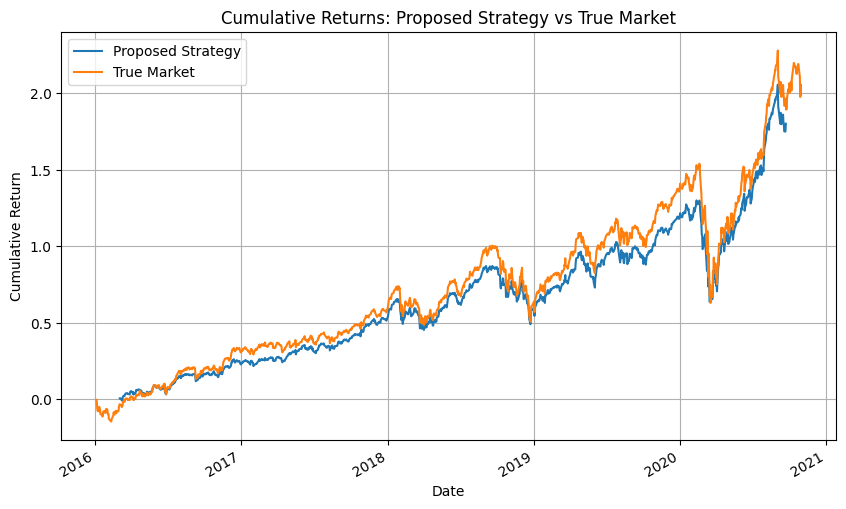

In [ ]:
# Cumulative returns, Annualized Volatility and Sharpe Ratio

dates = log_returns.index[window:]
strategy_series = pd.Series(strategy_returns, index=dates)
strategy_cum = np.exp(np.cumsum(strategy_series)) - 1

volatility = np.std(strategy_series) * np.sqrt(252)
sharpe_ratio = (np.mean(strategy_series) * 252) / volatility

print("Annualized Volatility:", round(volatility, 4))
print("Annualized Sharpe Ratio:", round(sharpe_ratio, 4))

plt.figure(figsize=(10,6))
strategy_cum.plot(label="Proposed Strategy")
benchmark_cumulative.plot(label="True Market")
plt.title("Cumulative Returns: Proposed Strategy vs True Market")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

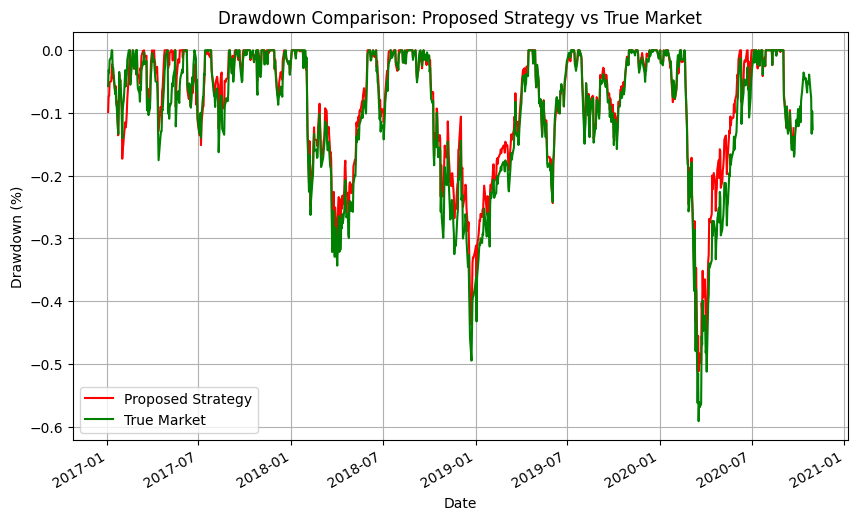

In [ ]:
# Comparison of drawdowns

running_max = np.maximum.accumulate(strategy_cum)
drawdown = (strategy_cum - running_max) / running_max

running_max3 = np.maximum.accumulate(benchmark_cumulative)
drawdown_3 = (benchmark_cumulative - running_max3) / running_max3

plt.figure(figsize=(10,6))
drawdown.plot(color="red", label="Proposed Strategy")
drawdown_3.plot(color = "green", label = "True Market")
plt.title("Drawdown Comparison: Proposed Strategy vs True Market")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.show()

## Compare the strategy with the baseline portfolio alone

In [ ]:
# Vanilla portfolios volatility and sharpe ratio

portfolio_returns_baseline = []

for t in range(window, len(log_returns)):
    if (t - window) % rebalance_freq == 0:
        window_data = log_returns.iloc[t-window:t-1, :]

        robust_vols = window_data.apply(lambda x: np.median(np.abs(x - np.median(x))) * 1.4826)
        base_weights = 1 / robust_vols
        base_weights /= base_weights.sum()
        current_weights = base_weights.copy()

    actual_returns = log_returns.iloc[t, :].values
    portfolio_returns_baseline.append(np.dot(current_weights, actual_returns))

dates = log_returns.index[window:]
baseline_series = pd.Series(portfolio_returns_baseline, index=dates)

baseline_cum = np.exp(np.cumsum(baseline_series)) - 1

volatility = np.std(baseline_series) * np.sqrt(252)
sharpe_ratio = (np.mean(baseline_series) * 252) / volatility

print("Annualized Volatility:", round(volatility, 4))
print("Annualized Sharpe Ratio:", round(sharpe_ratio, 4))


Annualized Volatility: 0.2254
Annualized Sharpe Ratio: 1.073


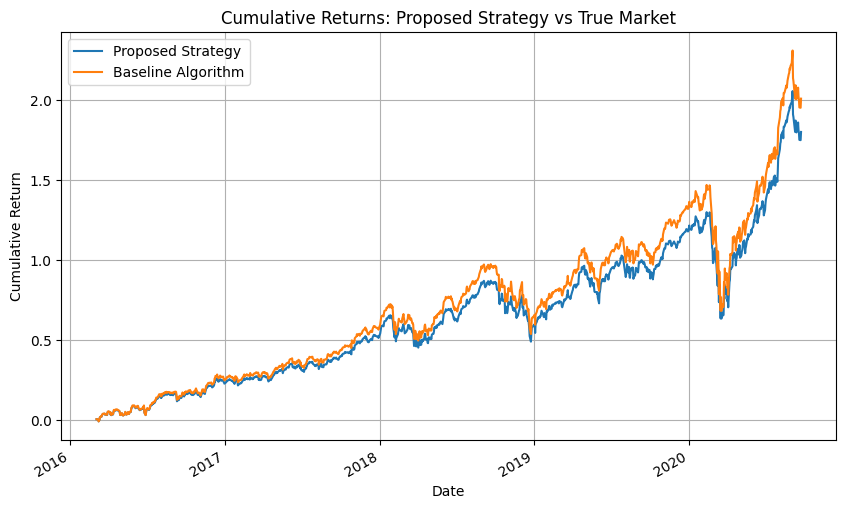

In [ ]:
# Cumulative return comparison
dates = log_returns.index[window:]
strategy_series = pd.Series(strategy_returns, index=dates)
strategy_cum = np.exp(np.cumsum(strategy_series)) - 1

plt.figure(figsize=(10,6))
strategy_cum.plot(label="Proposed Strategy")
baseline_cum.plot(label="Baseline Algorithm")
plt.title("Cumulative Returns: Proposed Strategy vs True Market")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

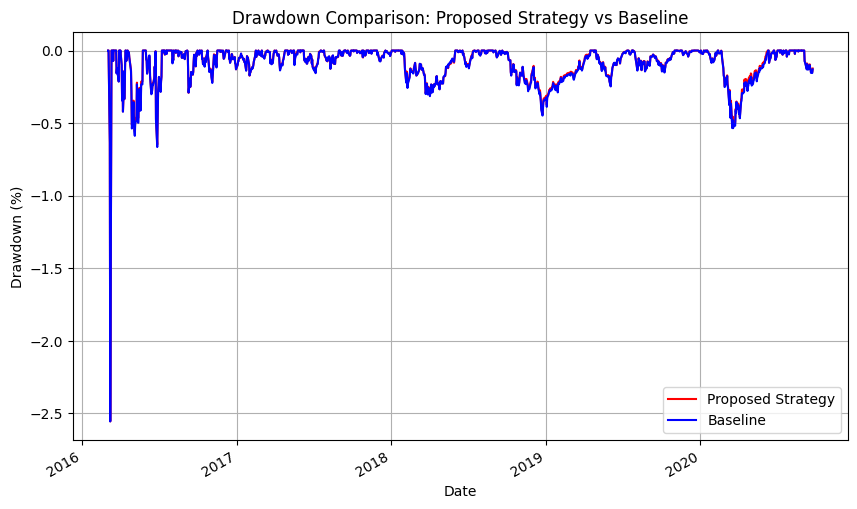

In [ ]:
# Drawdown comparison

running_max = np.maximum.accumulate(strategy_cum)
drawdown = (strategy_cum - running_max) / running_max

running_max2 = np.maximum.accumulate(baseline_cum)
drawdown_2 = (baseline_cum - running_max2) / running_max2

plt.figure(figsize=(10,6))
drawdown.plot(color="red", label="Proposed Strategy")
drawdown_2.plot(color="blue", label="Baseline")
plt.title("Drawdown Comparison: Proposed Strategy vs Baseline")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.show()